# Attribution-distribution uncertainty

Hypothesis (high-uncertainty eval point):
- **Aleatoric**: attributions concentrated on a small subset with strong **positive and negative** values (evidence for and against).
- **Epistemic**: attributions **uniform and low** everywhere (model lacks evidence).

## Measures (full training vector \(T_i\), not top-k only)
Let \(a_i = |T_i|\), \(p_i = a_i / \sum_j a_j\):
- **Attribution entropy** \(= -\sum p_i \log p_i / \log N\) — high when spread/uniform (epistemic).
- **Participation ratio** \(= (\sum a_i)^2 / (N \sum a_i^2)\) — high when many supporters contribute (epistemic).
- **Signed split** \(= 2\min(\text{pos}, \text{neg}) / (\text{pos}+\text{neg})\) — high when for-and-against (aleatoric).
- **Variance** \(\mathrm{var}(T_i)\) — magnitude spread (notebook reports empirical direction).

Existing top-k structure signals: `inverse_coherence` \(\approx 1 - |\sum T|/\sum|T|\), `inverse_dominance`, `inverse_mass`.

**Note:** Rebuilding DualXDA attributions requires `dualxda` + `zennit` in the active environment (same as full experiment runs).

In [11]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "uqlab").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from uqlab.evaluation.metrics.scoring import binary_auroc_vs_group
from uqlab.evaluation.signals.catalog import signal_labels
from uqlab.run_artifacts import GROUP_ALEATORIC, GROUP_EPISTEMIC, load_per_sample_table
from uqlab.shared.notebook_utils.attribution_rebuild import rebuild_tracer_and_attr
from uqlab.shared.config.classification import ExperimentConfig
from uqlab.runner.execute import run_from_python_config

REGION_ORDER = ["clean", "aleatoric_like", "epistemic_like", "ood_like"]
NON_SIGNAL = {"group", "dataset_index", "clean_label", "noisy_label", "is_noisy"}
DIST_COLS = [
    "attribution_entropy_dualxda",
    "attribution_participation_dualxda",
    "attribution_signed_split_dualxda",
    "attribution_variance_dualxda",
]
BASELINE_COLS = [
    "inverse_coherence_dualxda",
    "inverse_dominance_dualxda",
    "inverse_mass_dualxda",
    "mutual_info",
    "predictive_entropy",
]
LABELS = signal_labels()

In [ ]:
# --- Config: load existing run OR run fresh four-region experiment ---
MODE = "run"  # "load" | "run"
RUN_DIR = PROJECT_ROOT / "results" / "my_run"
DEVICE = "auto"  # cpu | mps | cuda | auto
MAX_EVAL_FOR_REBUILD = 200  # cap DualXDA recompute for notebook speed

RUN_ARCH = "dinov2_mlp"  # or "cnn_mcdropout" (needs training_scope=full, slower)

if MODE == "run":
    cfg_path = PROJECT_ROOT / "configs/experiment/four_region.yaml"
    config = ExperimentConfig.from_yaml(cfg_path)
    if RUN_ARCH == "cnn_mcdropout":
        config.model = config.model.model_copy(
            update={"architecture": "cnn_mcdropout", "training_scope": "full"}
        )
    config.training.epochs = 5
    config.evaluation.signals = {
        "predictive": ["msp_uncertainty", "predictive_entropy", "expected_entropy", "mutual_info"],
        "logit": ["inverse_logit_magnitude"],
        "attribution": [
            "inverse_coherence_dualxda",
            "inverse_dominance_dualxda",
            "inverse_mass_dualxda",
            *DIST_COLS,
        ],
    }
    out_dir = PROJECT_ROOT / "results" / "attribution_dist_notebook_run"
    device_str = None if DEVICE == "auto" else DEVICE
    summary = run_from_python_config(config, out_dir, seed=42, device_str=device_str)
    RUN_DIR = out_dir
    print("Run complete:", json.dumps({k: summary.get(k) for k in ("eval_sizes",)}, indent=2))
else:
    print(f"Loading run from {RUN_DIR}")

Loading run from /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/results/my_run


In [13]:
df = load_per_sample_table(RUN_DIR, max_rows=None)
if df is None:
    raise FileNotFoundError(f"No per_sample_signals.csv in {RUN_DIR}")

signal_cols = [c for c in df.columns if c not in NON_SIGNAL and pd.api.types.is_numeric_dtype(df[c])]
print(f"{len(df)} eval rows, {len(signal_cols)} signal columns")
df.head()

500 eval rows, 8 signal columns


,group,dataset_index,clean_label,noisy_label,is_noisy,mutual_info,msp_uncertainty,predictive_entropy,inverse_coherence_dualxda,inverse_mass_dualxda,inverse_dominance_dualxda,expected_entropy,inverse_logit_magnitude
0,clean,8187,7,7,False,0.010845,0.012547,0.077976,0.772024,0.000640,0.858147,0.067131,0.119729
1,clean,29150,2,2,False,0.134396,0.611723,1.648035,0.947079,0.001173,0.882105,1.513639,0.411109
2,clean,49754,6,6,False,0.051281,0.064250,0.332363,0.643700,0.000562,0.881057,0.281083,0.189813
3,clean,437,6,6,False,0.156642,0.233622,0.852729,0.916393,0.000589,0.874818,0.696087,0.223552
4,clean,11817,1,1,False,0.079966,0.369959,1.248867,0.424610,0.001050,0.874649,1.168902,0.340126


In [14]:
# Merge recomputed full-vector measures if missing from CSV (older runs)
missing_dist = [c for c in DIST_COLS if c not in df.columns]
if missing_dist:
    dev = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    rebuilt = rebuild_tracer_and_attr(RUN_DIR, device=dev, max_eval_samples=MAX_EVAL_FOR_REBUILD)
    n = rebuilt["attr"].shape[0]
    df_sub = df.iloc[:n].copy().reset_index(drop=True)
    df_sub["attribution_entropy_dualxda"] = rebuilt["distribution"]["entropy"].numpy()
    df_sub["attribution_participation_dualxda"] = rebuilt["distribution"]["participation"].numpy()
    df_sub["attribution_signed_split_dualxda"] = rebuilt["distribution"]["signed_split"].numpy()
    df_sub["attribution_variance_dualxda"] = rebuilt["distribution"]["variance"].numpy()
    df = df_sub
    attr_matrix = rebuilt["attr"]
    group_labels_t = rebuilt["group_labels"]
else:
    dev = torch.device("cpu")
    rebuilt = rebuild_tracer_and_attr(RUN_DIR, device=dev, max_eval_samples=min(64, len(df)))
    attr_matrix = rebuilt["attr"]
    df = df.iloc[: attr_matrix.shape[0]].copy().reset_index(drop=True)
    group_labels_t = rebuilt["group_labels"]

for c in DIST_COLS:
    if c not in df.columns:
        raise KeyError(c)

,attribution_entropy_dualxda,attribution_participation_dualxda,attribution_signed_split_dualxda,attribution_variance_dualxda,inverse_coherence_dualxda,inverse_dominance_dualxda,inverse_mass_dualxda,mutual_info,predictive_entropy
group,,,,,,,,,
clean,0.6301,0.0352,0.9961,3.2128,0.7755,0.8658,0.0009,0.0963,0.9288
aleatoric_like,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
epistemic_like,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ood_like,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


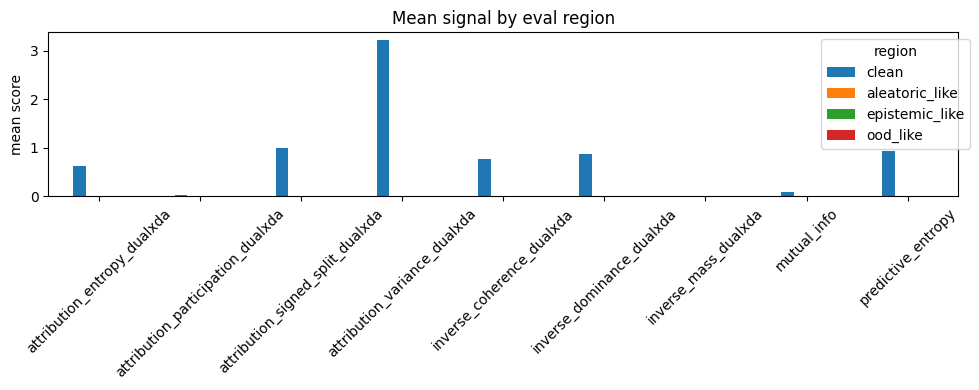

In [15]:
# Region means (like plot_run_region_means.py)
plot_cols = [c for c in DIST_COLS + BASELINE_COLS if c in df.columns]
means = df.groupby("group")[plot_cols].mean().reindex(REGION_ORDER)
display(means.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
means.T.plot(kind="bar", ax=ax, rot=45)
ax.tick_params(axis="x", labelrotation=45)
ax.set_title("Mean signal by eval region")
ax.set_ylabel("mean score")
ax.legend(title="region", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_52944/4089629020.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_52944/4089629020.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_52944/4089629020.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_52944/4089629020.py:8: Matplotli

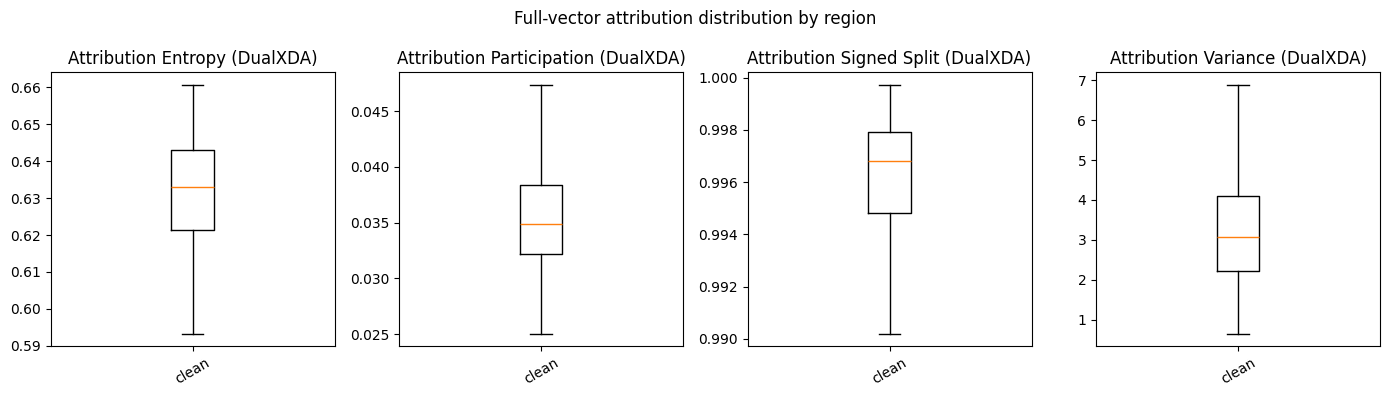

In [16]:
# Per-region boxplots for new distribution measures
fig, axes = plt.subplots(1, len(DIST_COLS), figsize=(14, 4))
if len(DIST_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, DIST_COLS):
    data = [df.loc[df["group"] == g, col].dropna().values for g in REGION_ORDER if g in df["group"].values]
    labels = [g for g in REGION_ORDER if g in df["group"].values]
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(LABELS.get(col, col))
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Full-vector attribution distribution by region")
plt.tight_layout()
plt.show()

,signal,label,auroc_alea_vs_epi
0,attribution_entropy_dualxda,Attribution Entropy (DualXDA),None
1,attribution_participation_dualxda,Attribution Participation (DualXDA),None
2,attribution_signed_split_dualxda,Attribution Signed Split (DualXDA),None
3,attribution_variance_dualxda,Attribution Variance (DualXDA),None
4,inverse_coherence_dualxda,Inverse Coherence (DualXDA),None
5,inverse_dominance_dualxda,Inverse Dominance (DualXDA),None
6,inverse_mass_dualxda,Inverse Mass (DualXDA),None
7,mutual_info,Mutual Information,None
8,predictive_entropy,Predictive Entropy,None


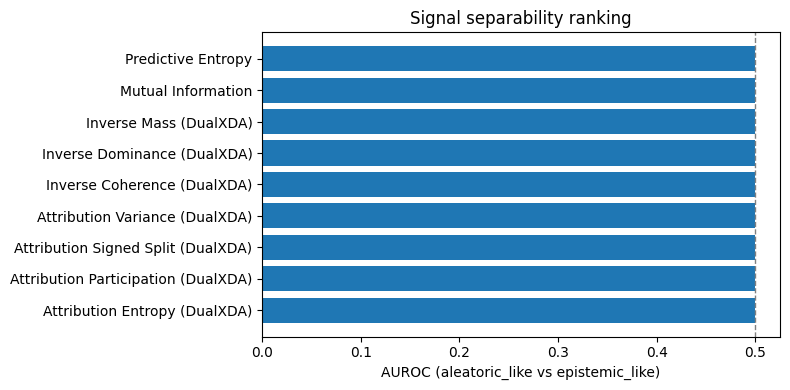

In [17]:
# AUROC: aleatoric_like vs epistemic_like (region separability)
GROUP_MAP = {"clean": 0, "aleatoric_like": 1, "epistemic_like": 2, "ood_like": 3}
mask = df["group"].isin(["aleatoric_like", "epistemic_like"])
sub = df.loc[mask].copy()
group_t = torch.tensor([GROUP_MAP[g] for g in sub["group"]], dtype=torch.long)

auroc_rows = []
for col in plot_cols:
    scores = torch.tensor(sub[col].values, dtype=torch.float32)
    auroc = binary_auroc_vs_group(
        scores,
        group_t,
        positive_group=GROUP_ALEATORIC,
        negative_group=GROUP_EPISTEMIC,
    )
    auroc_rows.append({"signal": col, "label": LABELS.get(col, col), "auroc_alea_vs_epi": auroc})

auroc_df = pd.DataFrame(auroc_rows).sort_values("auroc_alea_vs_epi", ascending=False)
display(auroc_df)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(auroc_df))))
ax.barh(auroc_df["label"], auroc_df["auroc_alea_vs_epi"].fillna(0.5))
ax.axvline(0.5, color="gray", ls="--", lw=1)
ax.set_xlabel("AUROC (aleatoric_like vs epistemic_like)")
ax.set_title("Signal separability ranking")
plt.tight_layout()
plt.show()

In [18]:
# Example attribution histograms: one aleatoric-like vs one epistemic-like point
def pick_row_pos(group_name: str, score_col: str) -> int:
    gdf = df[df["group"] == group_name]
    if gdf.empty:
        raise ValueError(group_name)
    return int(gdf[score_col].values.argmax())

if len(attr_matrix) > 0:
    alea_pos = pick_row_pos("aleatoric_like", "attribution_signed_split_dualxda")
    epi_pos = pick_row_pos("epistemic_like", "attribution_entropy_dualxda")
    g_alea = df[df["group"] == "aleatoric_like"]
    g_epi = df[df["group"] == "epistemic_like"]
    alea_idx = int(g_alea.index[alea_pos])
    epi_idx = int(g_epi.index[epi_pos])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, idx, title in [
        (axes[0], alea_idx, "Aleatoric-like (high signed split)"),
        (axes[1], epi_idx, "Epistemic-like (high entropy)"),
    ]:
        row = attr_matrix[min(idx, attr_matrix.shape[0] - 1)].numpy()
        ax.hist(row, bins=40, color="steelblue", alpha=0.85)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(title)
        ax.set_xlabel("DualXDA attribution T_i")
        ax.set_ylabel("count (train index)")
    plt.suptitle("Full attribution vector shape")
    plt.tight_layout()
    plt.show()

ValueError: aleatoric_like

## Conclusion
Rank signals by `auroc_alea_vs_epi` above. Full-vector **entropy/participation** should rank higher for epistemic separation vs top-k-only proxies when attributions are uniformly low; **signed_split** should complement **inverse_coherence** for aleatoric conflict.